# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)
        print('signal     :', a.signal)
        print('background :', a.background)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1627.41690314 3201.88327543 4650.45957095 5924.09370901 7066.49291734]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 134 v_min bins, peak flux 7.92e+02
signal     : [177.69576219 391.69782578 600.62630605 772.20793827 953.63516523]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 84 v_min bins, peak flux 8.25e+01
signal     : [19.36823774 38.38170803 56.61092362 76.04268319 96.33501826]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 8.27e+00


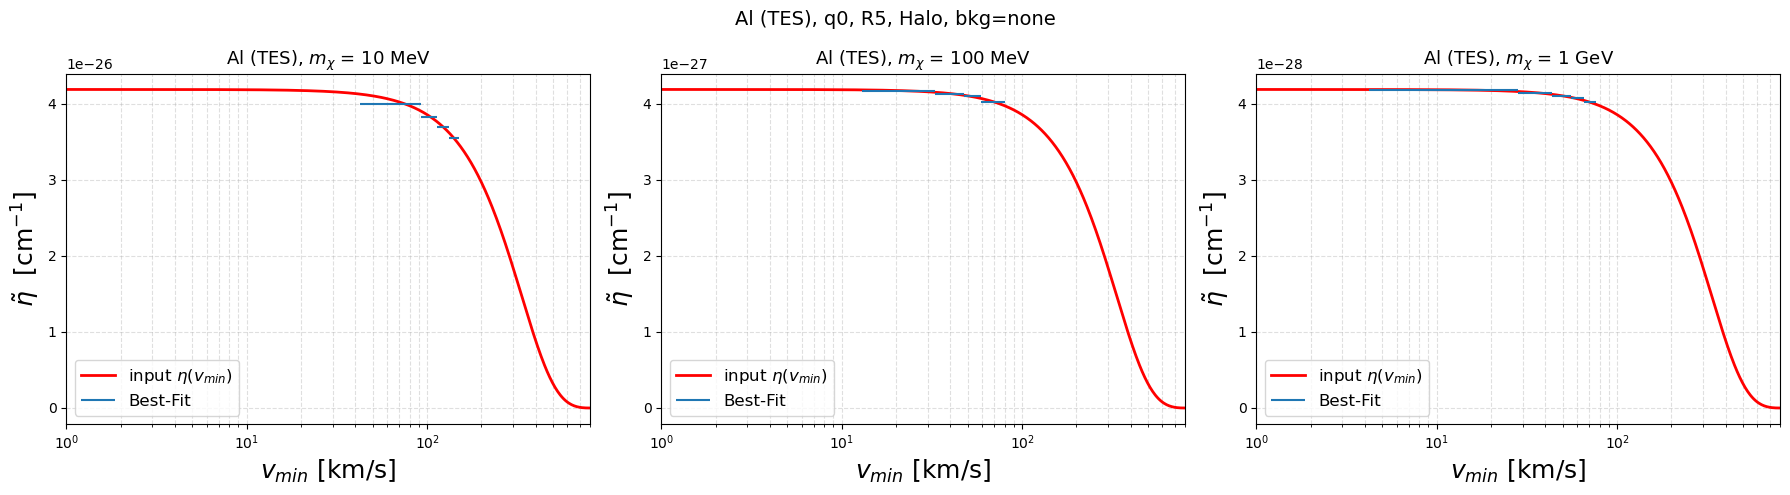

In [2]:
run_masses('Al', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1694.36516322 2834.42659263 3328.15577966 3763.76785775 4076.25059076]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 160 v_min bins, peak flux 8.04e+02
signal     : [140.90038297 278.07236604 409.93185265 528.15537647 626.84828132]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 8.12e+01
signal     : [14.92797945 29.4196361  42.64002131 54.14731232 63.6671201 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 365 v_min bins, peak flux 8.16e+00


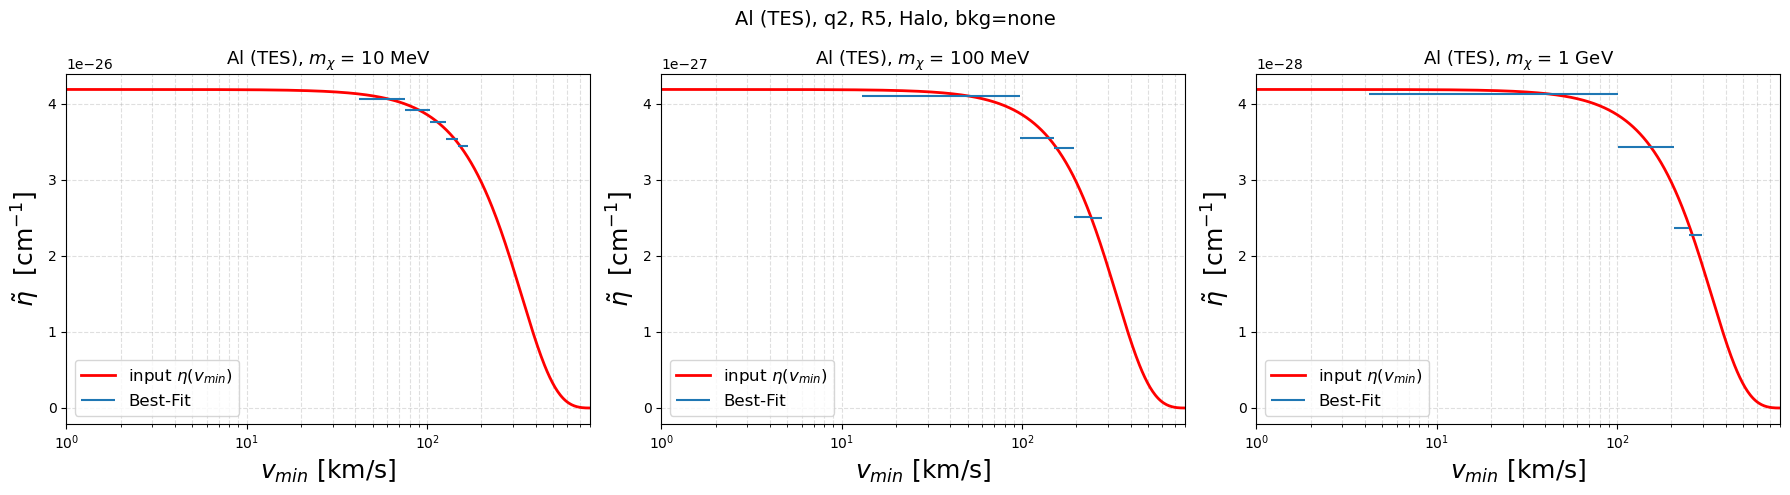

In [3]:
run_masses('Al', q='2', nbins=5, eta='Halo', solver = 'osqp')

### Heavy mediator (q0), 10 energy bins

signal     : [ 632.608654   1066.68572795 1471.20811312 1865.22099421 2226.16904981
 2600.02459693 2940.45974913 3225.03161592 3518.42836624 3769.26973268]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 135 v_min bins, peak flux 8.31e+02
signal     : [ 64.39935107 109.19463062 167.70758906 220.02796985 273.52978013
 329.08131337 375.80322209 417.83047516 465.16500839 513.61083694]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 85 v_min bins, peak flux 8.26e+01
signal     : [ 7.49246586 12.29837613 16.62087472 20.96990425 25.99632296 31.12474921
 36.49519364 41.75525368 47.17882294 52.33788626]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

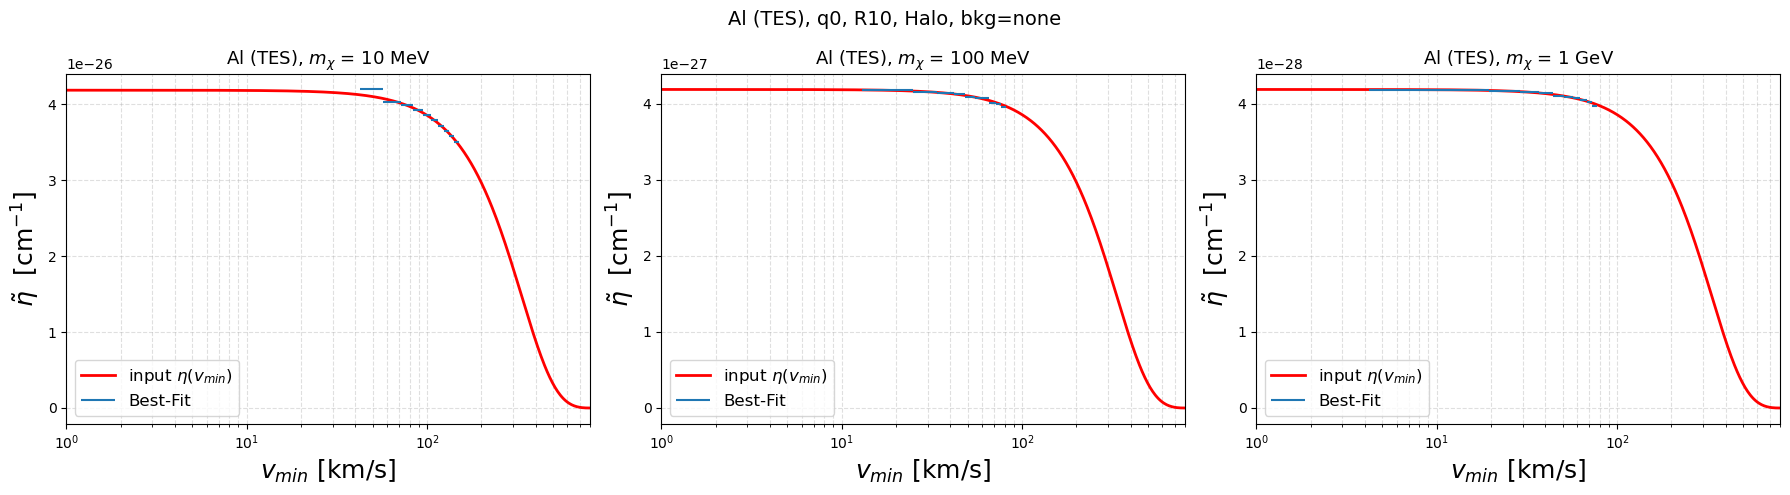

In [4]:
run_masses('Al', q='0', nbins=10, eta='Halo', solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 634.37200285 1002.01608379 1262.81162953 1510.79086005 1632.93446539
 1663.09031686 1628.60853395 1721.71292126 1910.94768834 1898.68423681]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 151 v_min bins, peak flux 8.13e+02
signal     : [ 50.23195123  86.83735601 123.50962633 160.44919096 196.02569269
 230.0655723  261.3626861  290.01610844 316.29763651 339.49680742]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 348 v_min bins, peak flux 8.21e+01
signal     : [ 5.77337258  9.83359409 13.60527172 17.2576189  20.69881666 23.98212786
 26.97919379 29.72338843 32.23474566 34.450634  ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

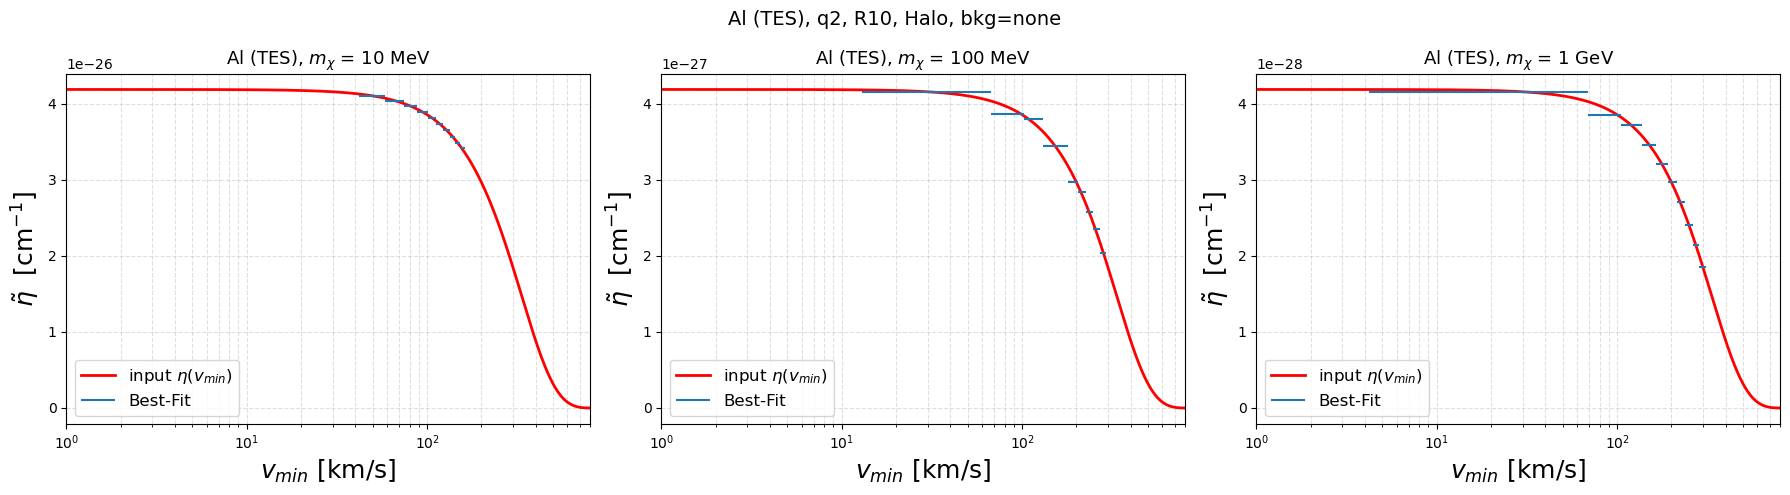

In [5]:
run_masses('Al', q='2', nbins=10, eta='Halo', solver = 'scipy')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1688.93587643 3281.51940908 4702.23999028 5912.86187753 6971.32018752]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 134 v_min bins, peak flux 8.35e+02
signal     : [ 192.84693471  423.84220248  647.51833784  829.0545829  1018.41027799]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 84 v_min bins, peak flux 8.94e+01
signal     : [ 21.05158429  41.66476708  61.32288888  82.10450698 103.53962805]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 8.98e+00


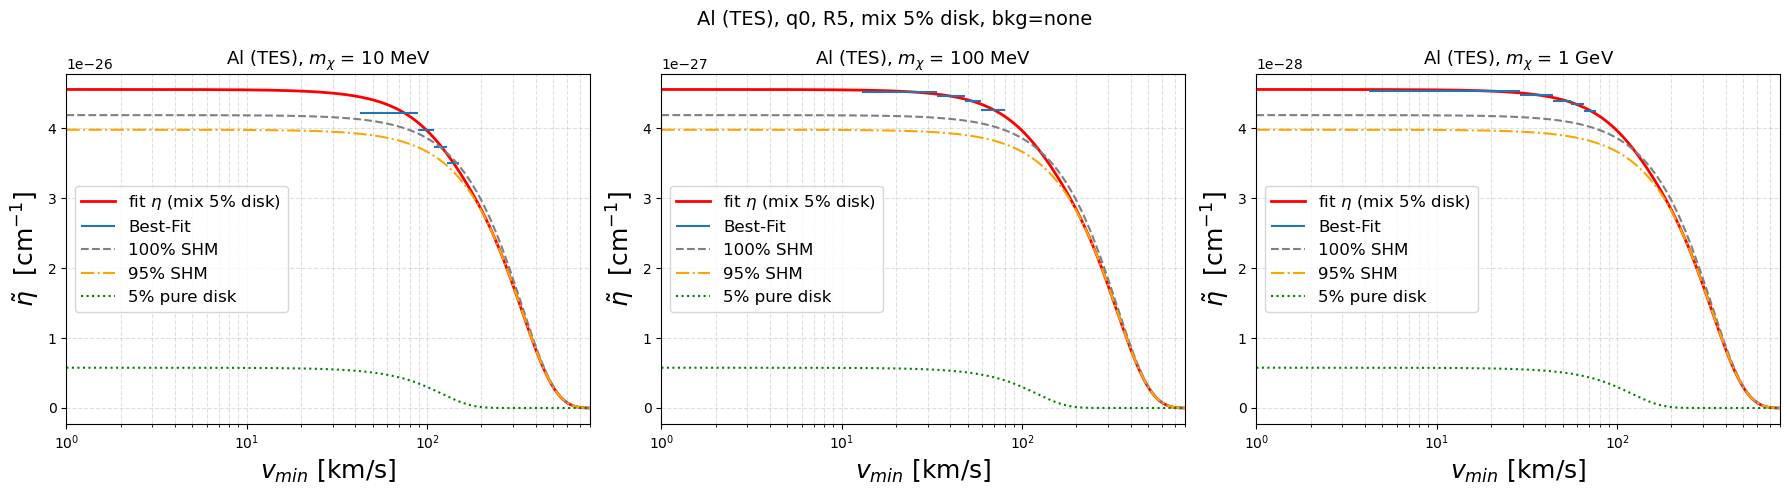

signal     : [1935.01176962 3600.06394369 4909.36166758 5867.93455159 6590.62926824]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 134 v_min bins, peak flux 1.03e+03
signal     : [ 253.45162481  552.41970929  835.08646499 1056.44116143 1277.51072902]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 84 v_min bins, peak flux 1.17e+02
signal     : [ 27.78497051  54.79700327  80.17074994 106.35180214 132.35806719]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 1.18e+01


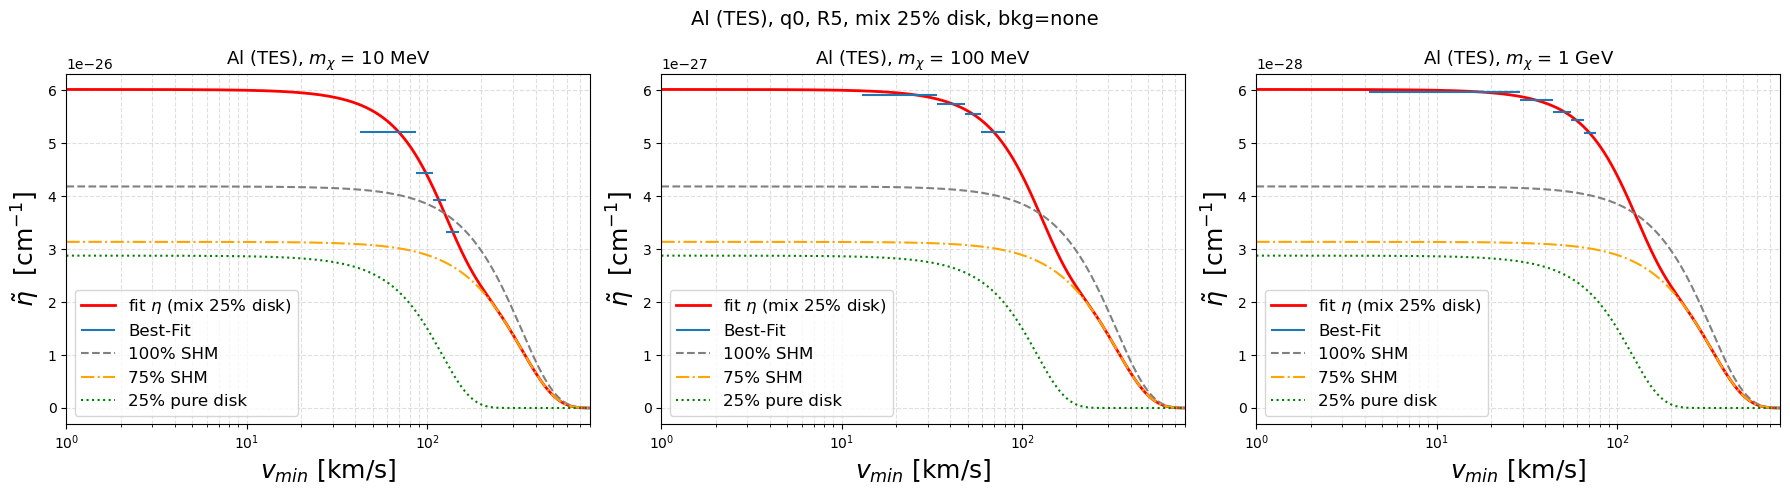

In [6]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1791.13105341 2931.22076867 3376.72291034 3751.82774662 4006.01755695]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 160 v_min bins, peak flux 8.67e+02
signal     : [152.45084133 297.04805452 429.12739898 542.0104595  633.30854263]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 8.83e+01
signal     : [16.15365054 31.39401211 44.60565691 55.62673734 64.4737042 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 365 v_min bins, peak flux 8.88e+00


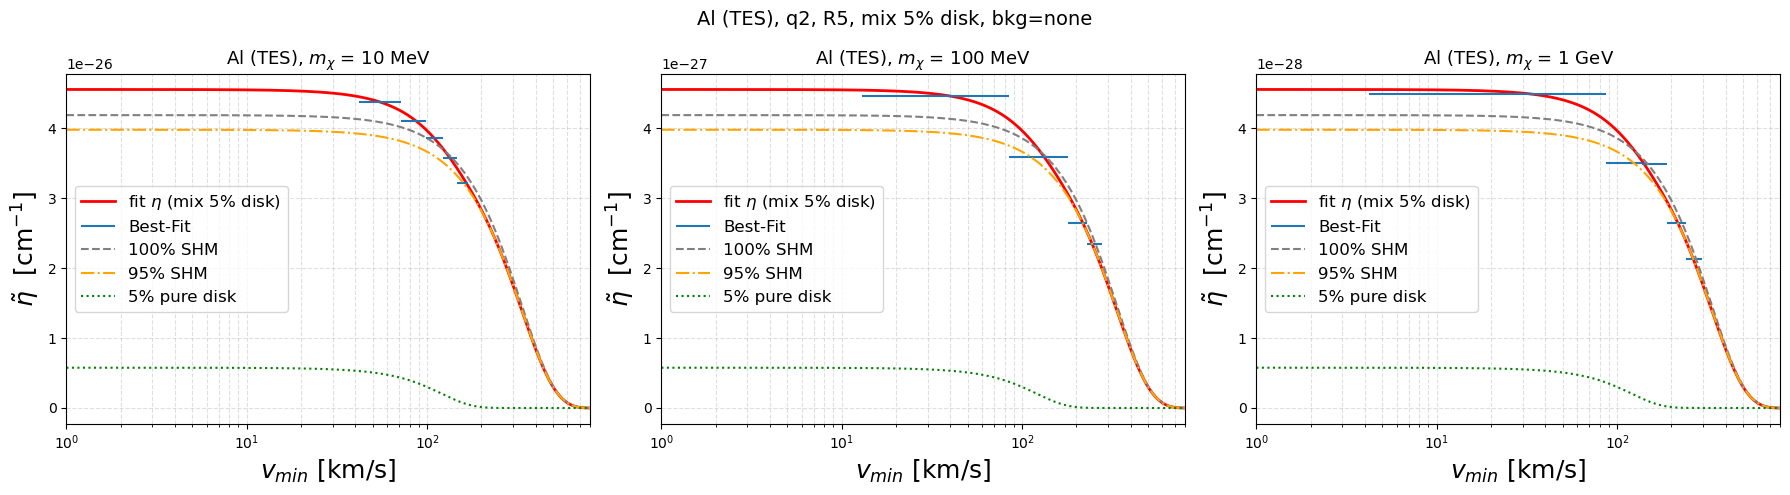

signal     : [2178.19461416 3318.3974728  3570.99143305 3704.06730208 3725.08542173]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 160 v_min bins, peak flux 1.11e+03
signal     : [198.65267474 372.95080845 505.90958433 597.4307916  659.14958786]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 1.16e+02
signal     : [21.05633489 39.29151615 52.46819933 61.54443741 67.70004061]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 365 v_min bins, peak flux 1.16e+01


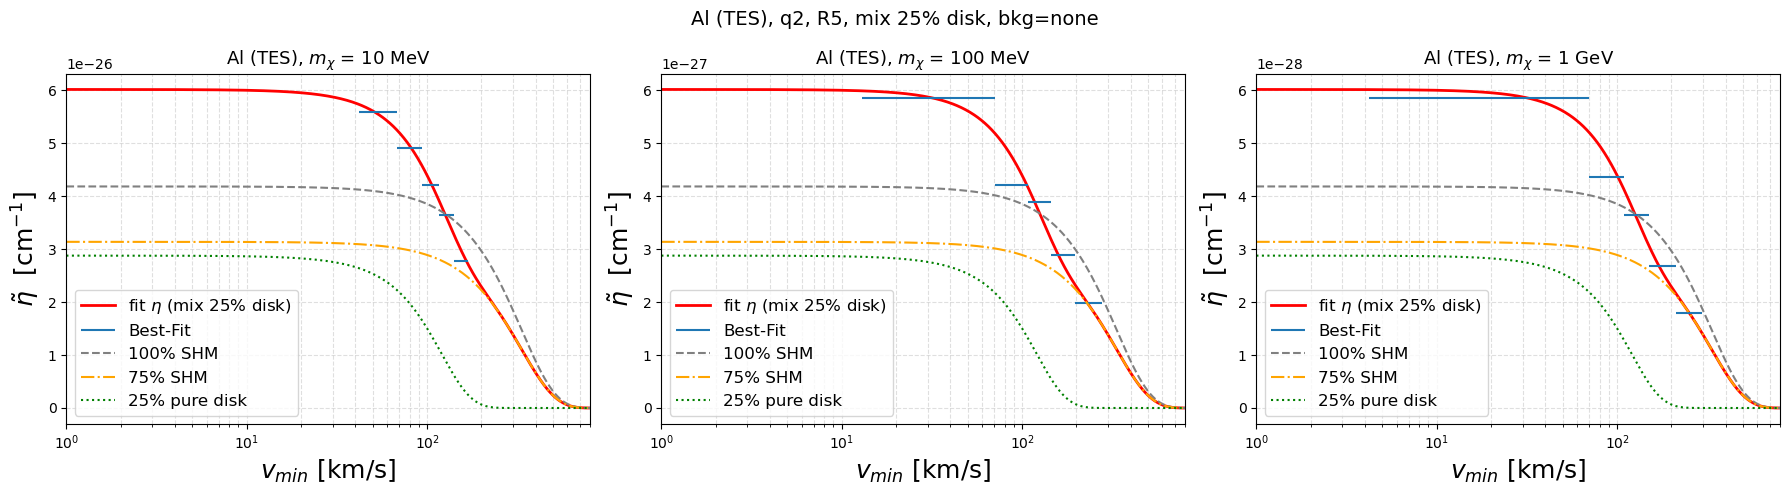

In [7]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 10 energy bins

signal     : [ 659.09195024 1104.69384167 1513.72947386 1906.0805146  2259.80340603
 2620.88100761 2944.60104778 3209.55456063 3481.01293437 3709.24645024]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix5/flux.pdf
Al q0 M1 R10: 10 E-bins x 135 v_min bins, peak flux 9.23e+02
signal     : [ 69.94071911 118.46163015 181.66575029 237.9572392  295.28312819
 354.52557052 404.00346805 448.18361736 497.654322   547.89588539]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix5/flux.pdf
Al q0 M2 R10: 10 E-bins x 85 v_min bins, peak flux 8.97e+01
signal     : [ 8.14572968 13.36529161 18.05246305 22.75888922 28.18435384 33.70002306
 39.45005415 45.04916241 50.7849158  56.19713428]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

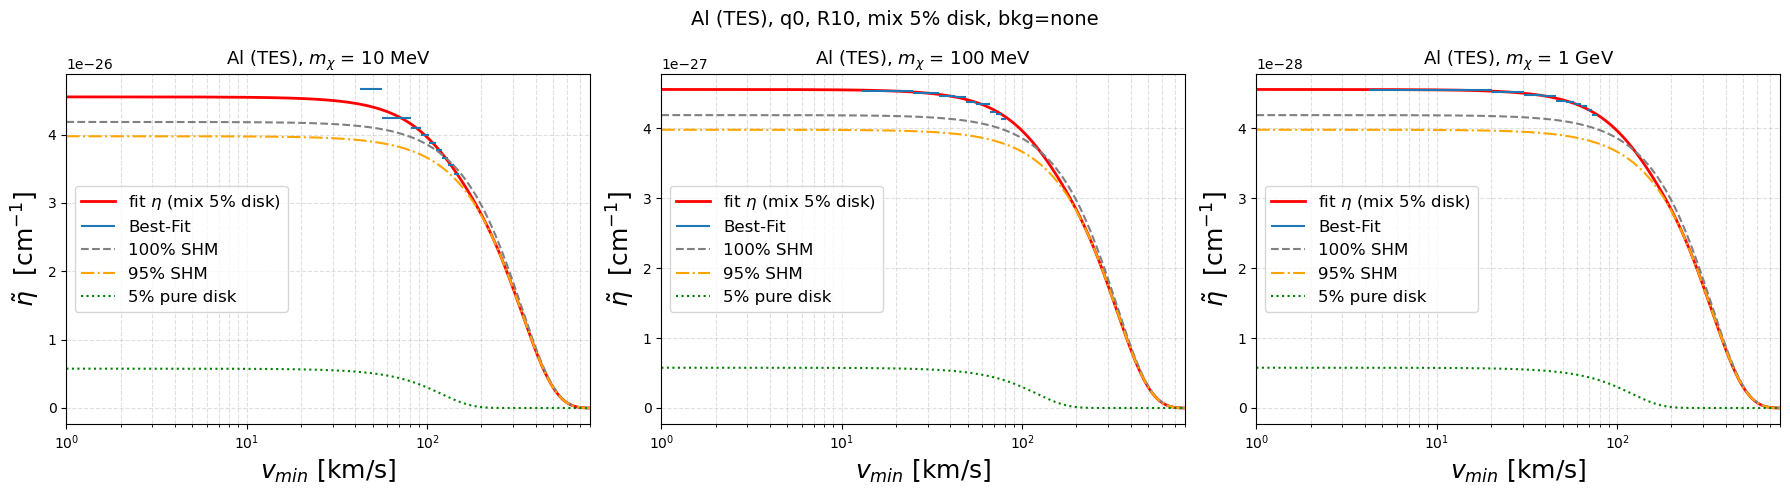

signal     : [ 765.0251352  1256.72629653 1683.81491686 2069.51859618 2394.34083092
 2704.30665036 2961.16624237 3147.64633947 3331.35120689 3469.15332051]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix25/flux.pdf
Al q0 M1 R10: 10 E-bins x 135 v_min bins, peak flux 1.17e+03
signal     : [ 92.10619127 155.52962827 237.49839519 309.6743166  382.29652045
 456.30259911 516.80445191 569.59618617 627.61157644 685.03607916]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix25/flux.pdf
Al q0 M2 R10: 10 E-bins x 85 v_min bins, peak flux 1.18e+02
signal     : [10.75878498 17.63295353 23.77881636 29.91482911 36.93647735 44.00111844
 51.26949616 58.22479733 65.20928722 71.63412638]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qu

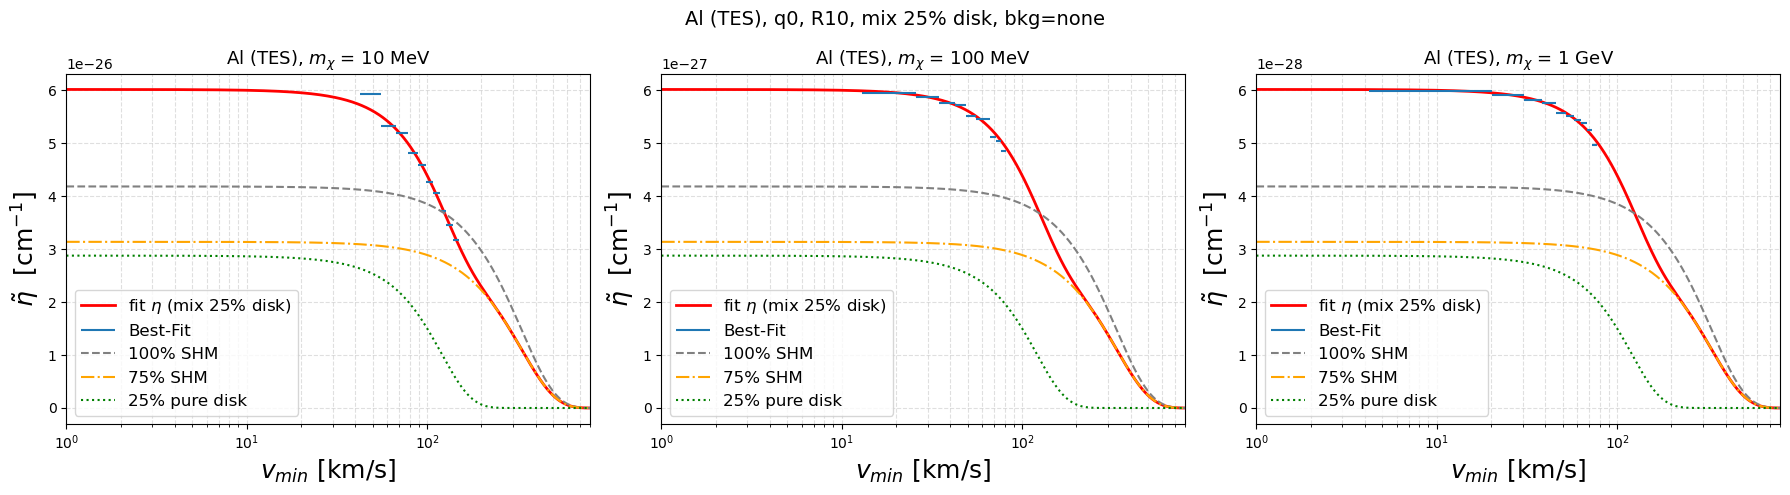

In [8]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=10, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 676.31828762 1056.24761073 1315.97597604 1556.26937516 1665.75992832
 1681.88374541 1634.45969502 1713.98197075 1886.6416854  1864.30061831]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix5/flux.pdf
Al q2 M1 R10: 10 E-bins x 151 v_min bins, peak flux 8.75e+02
signal     : [ 54.49316234  93.85553362 132.65756834 170.81528417 206.49594802
 239.71748378 269.56022896 296.41383594 320.72685535 341.88894993]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix5/flux.pdf
Al q2 M2 R10: 10 E-bins x 348 v_min bins, peak flux 8.89e+01
signal     : [ 6.26281849 10.61937244 14.58684621 18.33278049 21.76726399 24.96967036
 27.83518824 30.41805573 32.75146357 34.78050693]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

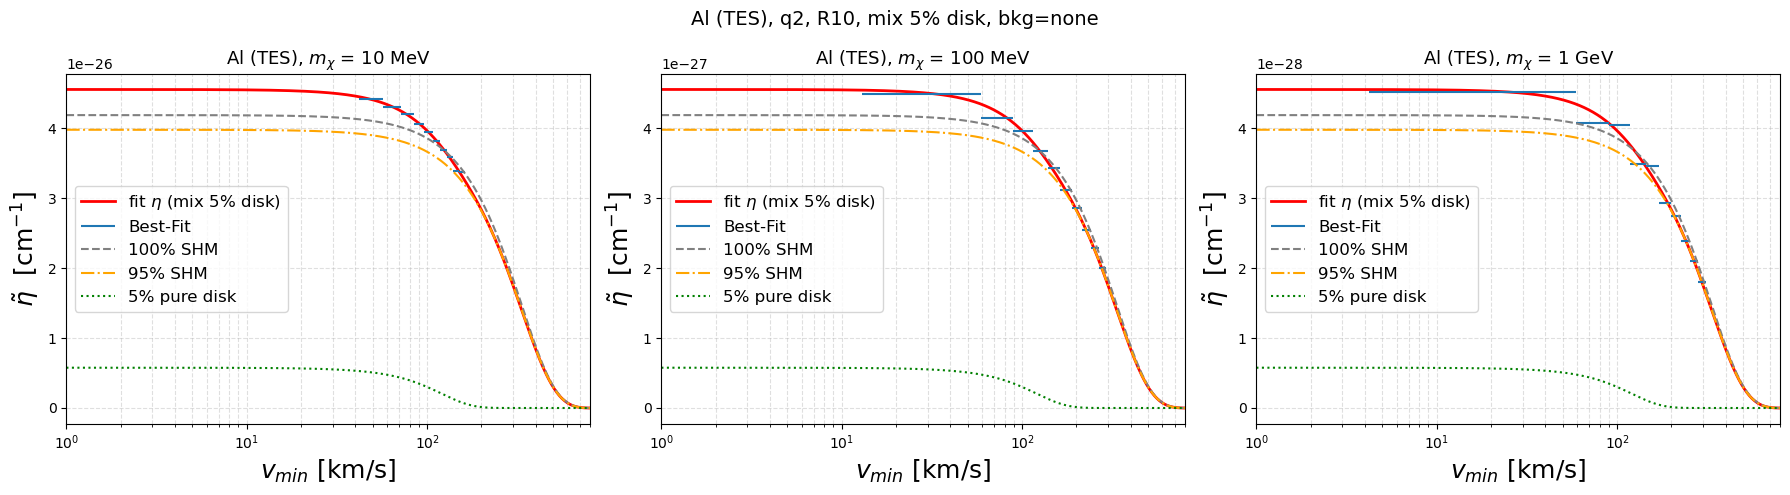

signal     : [ 844.10342671 1273.17371851 1528.63336205 1738.18343561 1797.06178002
 1757.05745961 1657.86433933 1683.05816867 1789.41767365 1726.76614432]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix25/flux.pdf
Al q2 M1 R10: 10 E-bins x 151 v_min bins, peak flux 1.11e+03
signal     : [ 71.53800679 121.92824409 169.2493364  212.27965698 248.37696932
 278.32512967 302.3504004  322.00474594 338.44373072 351.45751998]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix25/flux.pdf
Al q2 M2 R10: 10 E-bins x 348 v_min bins, peak flux 1.17e+02
signal     : [ 8.2206021  13.7624858  18.51314414 22.63342686 26.04105329 28.91984033
 31.25916604 33.19672492 34.8183352  36.09999868]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Q

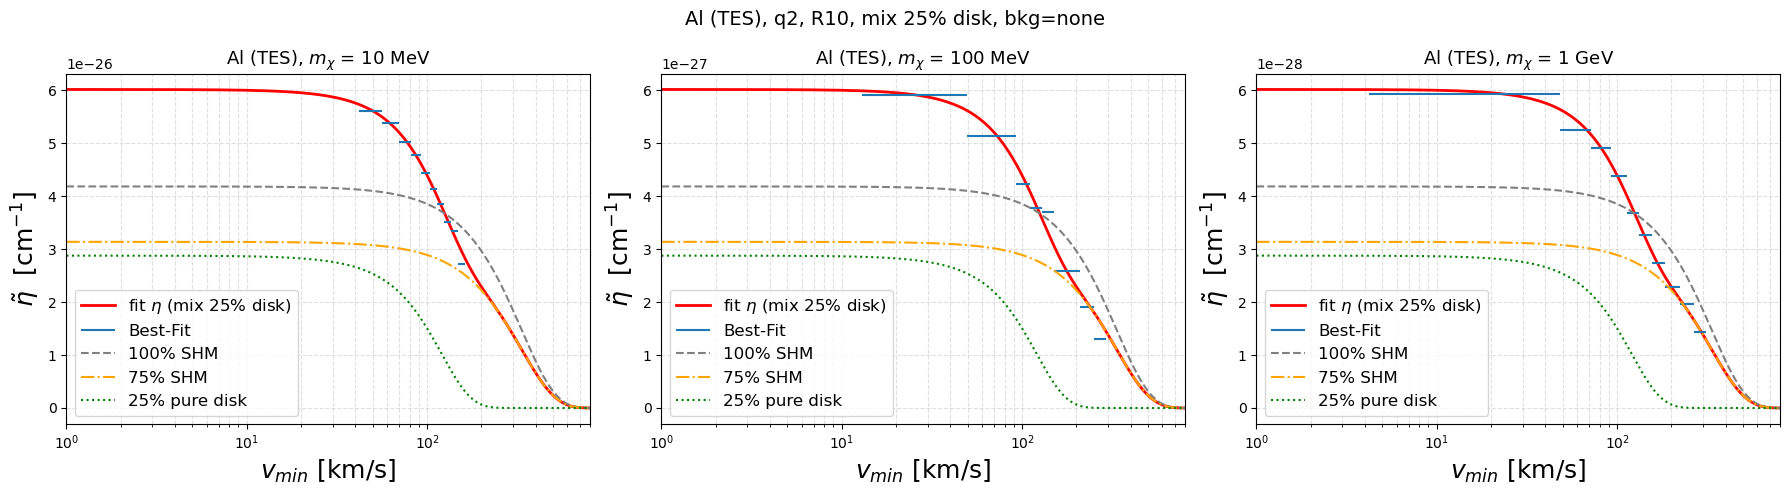

In [9]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=10, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [2.36412745e+14 2.38842861e+11 1.43354707e+08 2.07249401e+04
 9.63350183e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 6.30e+14


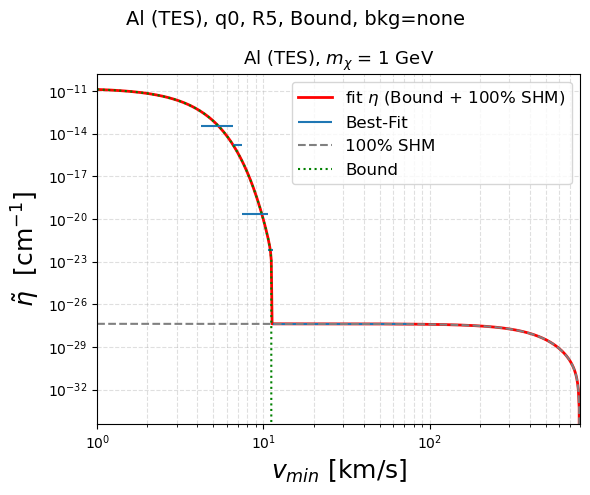

In [10]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [2.01745002e+12 1.80023142e+08 6.40471967e+04 5.74726246e+01
 6.36671201e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Bound/flux.pdf
Al q2 M3 R5: 5 E-bins x 365 v_min bins, peak flux 2.40e+14


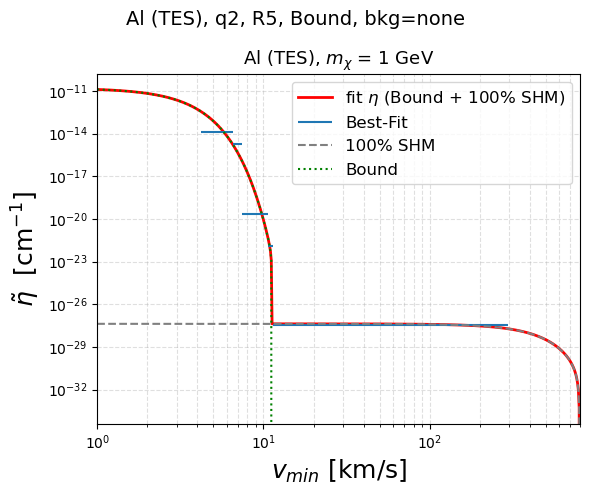

In [11]:
run_masses('Al', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 10 energy bins

signal     : [2.28806892e+14 9.73575431e+12 2.34242992e+11 6.25499600e+09
 1.41881745e+08 2.50623738e+06 2.06853926e+04 4.17552537e+01
 4.71788229e+01 5.23378863e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 92 v_min bins, peak flux 1.39e+15


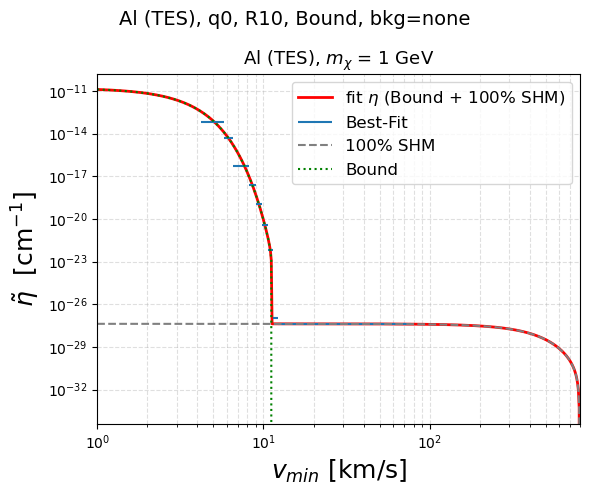

In [12]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

### Light mediator (q2), 10 energy bins

signal     : [2.00747570e+12 1.37129880e+10 1.78148202e+08 2.70657800e+06
 6.37421068e+04 6.34604058e+02 3.03045061e+01 2.97233884e+01
 3.22347457e+01 3.44506340e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Bound/flux.pdf
Al q2 M3 R10: 10 E-bins x 383 v_min bins, peak flux 1.05e+15


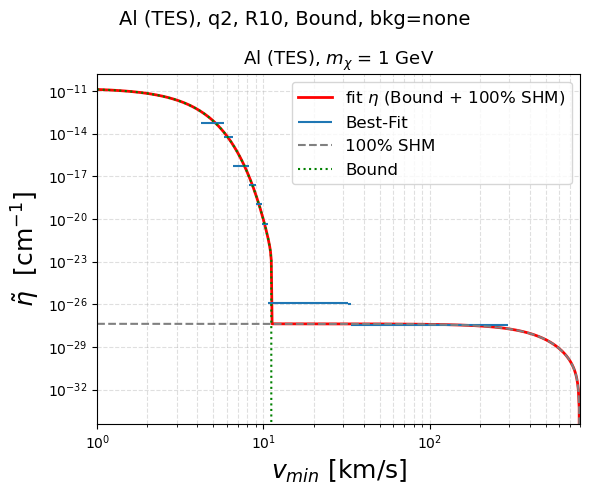

In [13]:
run_masses('Al', q='2', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [1627.41690314 3201.88327543 4650.45957095 5924.09370901 7066.49291734]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M1 R5: 5 E-bins x 134 v_min bins, peak flux 7.92e+02
signal     : [177.69576219 391.69782578 600.62630605 772.20793827 953.63516523]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M2 R5: 5 E-bins x 84 v_min bins, peak flux 8.25e+01
signal     : [19.36823774 38.38170803 56.61092362 76.04268319 96.33501826]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 8.27e+00


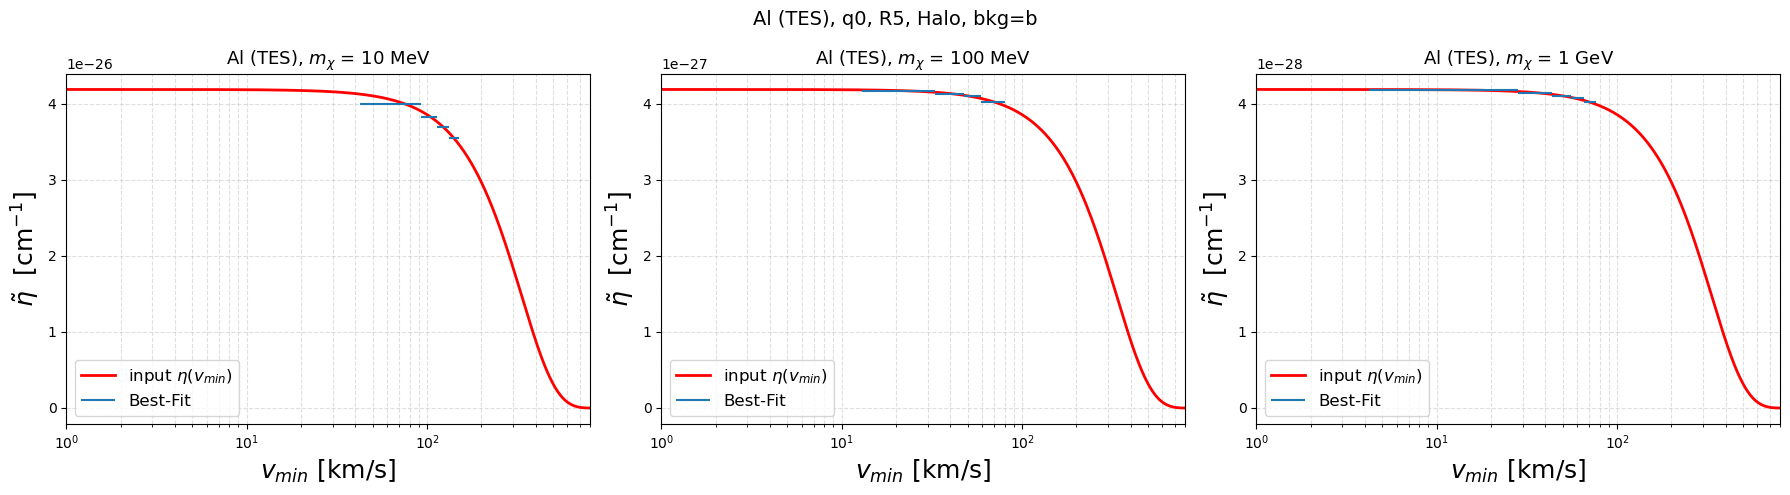

In [14]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='b', solver = 'scipy', save = False)

signal     : [1694.36516322 2834.42659263 3328.15577966 3763.76785775 4076.25059076]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M1 R5: 5 E-bins x 160 v_min bins, peak flux 8.04e+02
signal     : [140.90038297 278.07236604 409.93185265 528.15537647 626.84828132]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 8.12e+01
signal     : [14.92797945 29.4196361  42.64002131 54.14731232 63.6671201 ]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M3 R5: 5 E-bins x 365 v_min bins, peak flux 8.16e+00


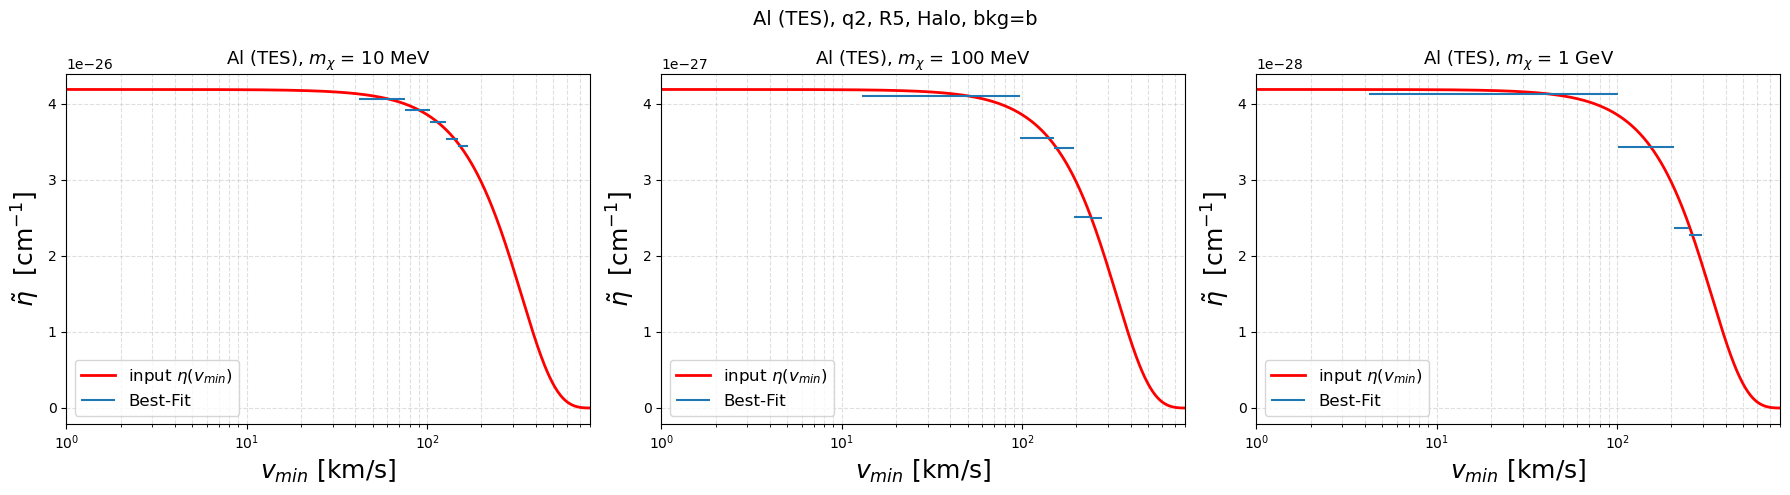

In [15]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='b', save = False)

signal     : [1627.41690314 3201.88327543 4650.45957095 5924.09370901 7066.49291734]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M1 R5: 5 E-bins x 134 v_min bins, peak flux 7.92e+02
signal     : [177.69576219 391.69782578 600.62630605 772.20793827 953.63516523]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M2 R5: 5 E-bins x 84 v_min bins, peak flux 8.25e+01
signal     : [19.36823774 38.38170803 56.61092362 76.04268319 96.33501826]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 8.27e+00


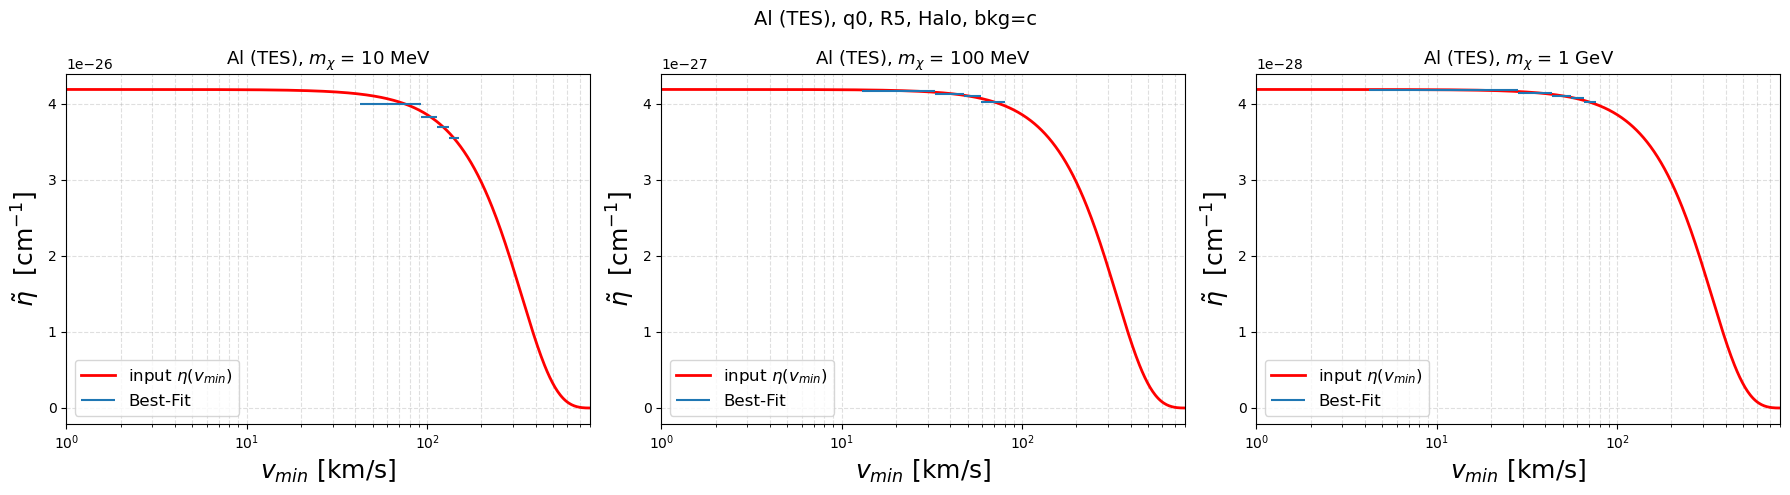

In [16]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='c', solver = 'scipy', save = False)

signal     : [1694.36516322 2834.42659263 3328.15577966 3763.76785775 4076.25059076]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M1 R5: 5 E-bins x 160 v_min bins, peak flux 8.04e+02
signal     : [140.90038297 278.07236604 409.93185265 528.15537647 626.84828132]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 8.12e+01
signal     : [14.92797945 29.4196361  42.64002131 54.14731232 63.6671201 ]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M3 R5: 5 E-bins x 365 v_min bins, peak flux 8.16e+00


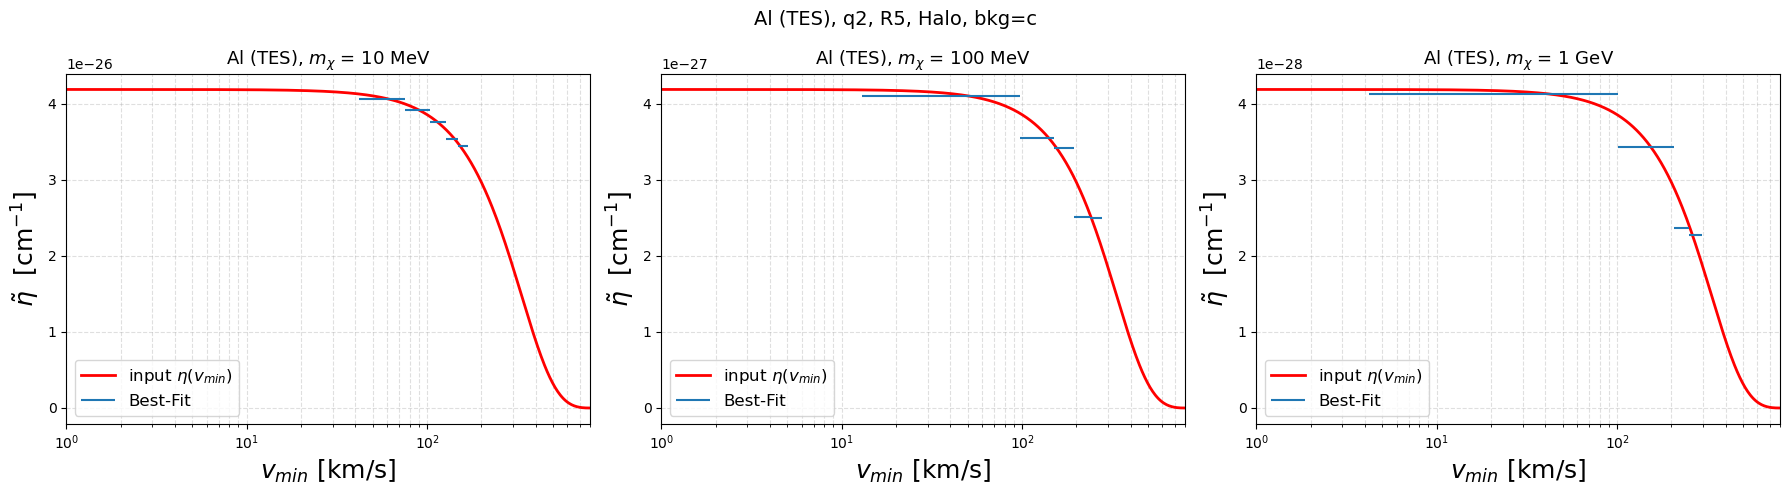

In [17]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='c', save = False)

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1295.98169779 3836.27094504 5296.07500654 6585.5103922  7845.03760584]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 136 v_min bins, peak flux 7.93e+02
signal     : [114.14888646 348.7762134  506.15462765 656.32808017 796.25297622]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 145 v_min bins, peak flux 8.19e+01
signal     : [11.34317172 34.67132336 50.46362839 65.50527952 79.63946999]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 157 v_min bins, peak flux 8.22e+00


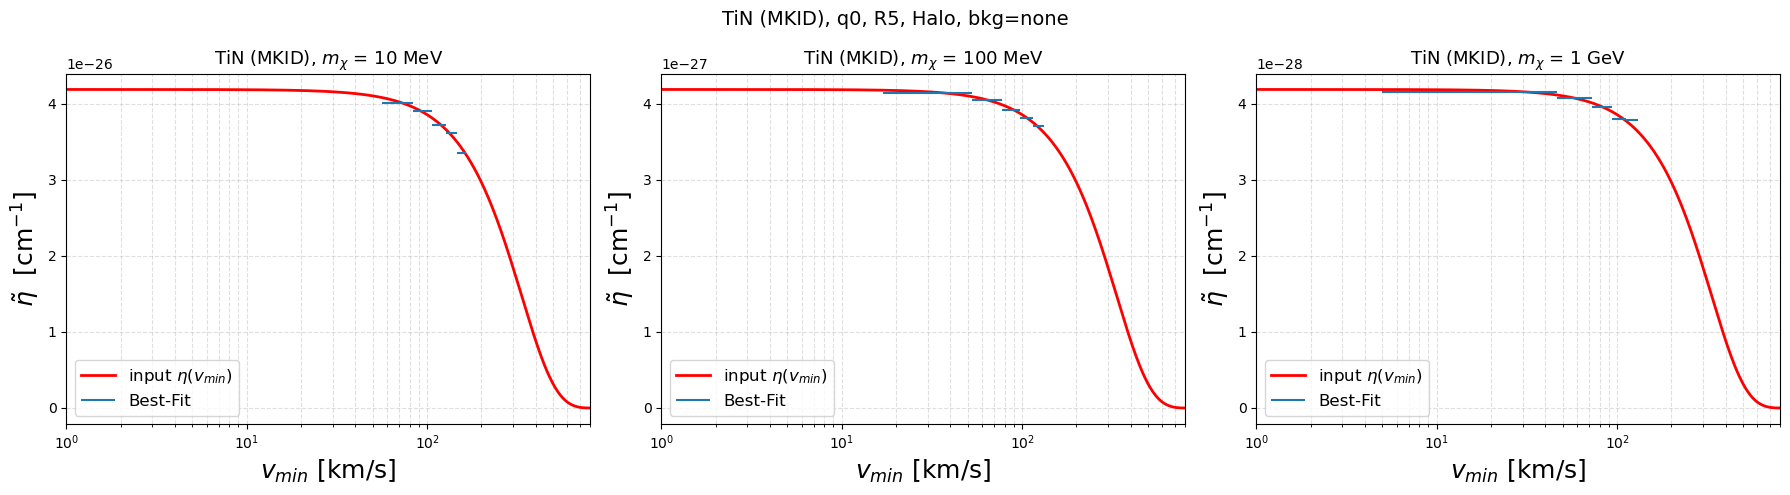

In [18]:
run_masses('TiN', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 6234.91651178 18243.62906177 22488.58916542 31189.07491243
 35852.74664103]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_Halo/flux.pdf
TiN q2 M1 R5: 5 E-bins x 333 v_min bins, peak flux 7.74e+02
signal     : [ 680.368839   2041.75533889 2840.05164377 3430.35048506 3807.41612879]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_Halo/flux.pdf
TiN q2 M2 R5: 5 E-bins x 488 v_min bins, peak flux 8.07e+01
signal     : [ 70.26270477 206.80159194 286.03929449 344.12057188 381.24399878]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Halo/flux.pdf
TiN q2 M3 R5: 5 E-bins x 514 v_min bins, peak flux 8.08e+00


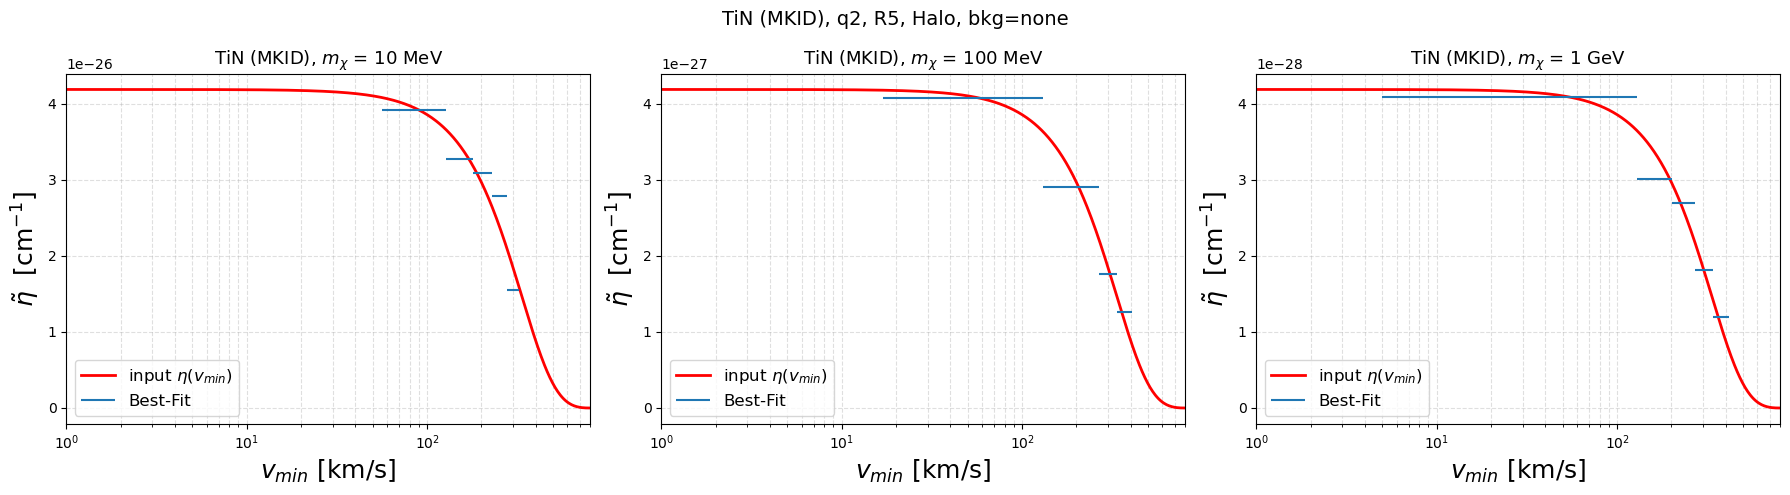

In [19]:
run_masses('TiN', q='2', nbins=5, eta='Halo')

### Heavy mediator (q0), 9 energy bins

signal     : [1295.98169779 1761.13928032 2172.31246146 2536.91561586 2839.430146
 3204.75722112 3545.60295295 3893.91496607 4209.3219541 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 140 v_min bins, peak flux 8.04e+02
signal     : [114.14888646 156.89644034 198.65733752 239.77623929 280.31838801
 320.18705399 358.85800273 395.99434215 431.55923373]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 150 v_min bins, peak flux 8.22e+01
signal     : [11.34317172 15.60203415 19.81364997 23.92122642 28.01864244 31.96261473
 35.83812259 39.56618712 43.18506333]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/

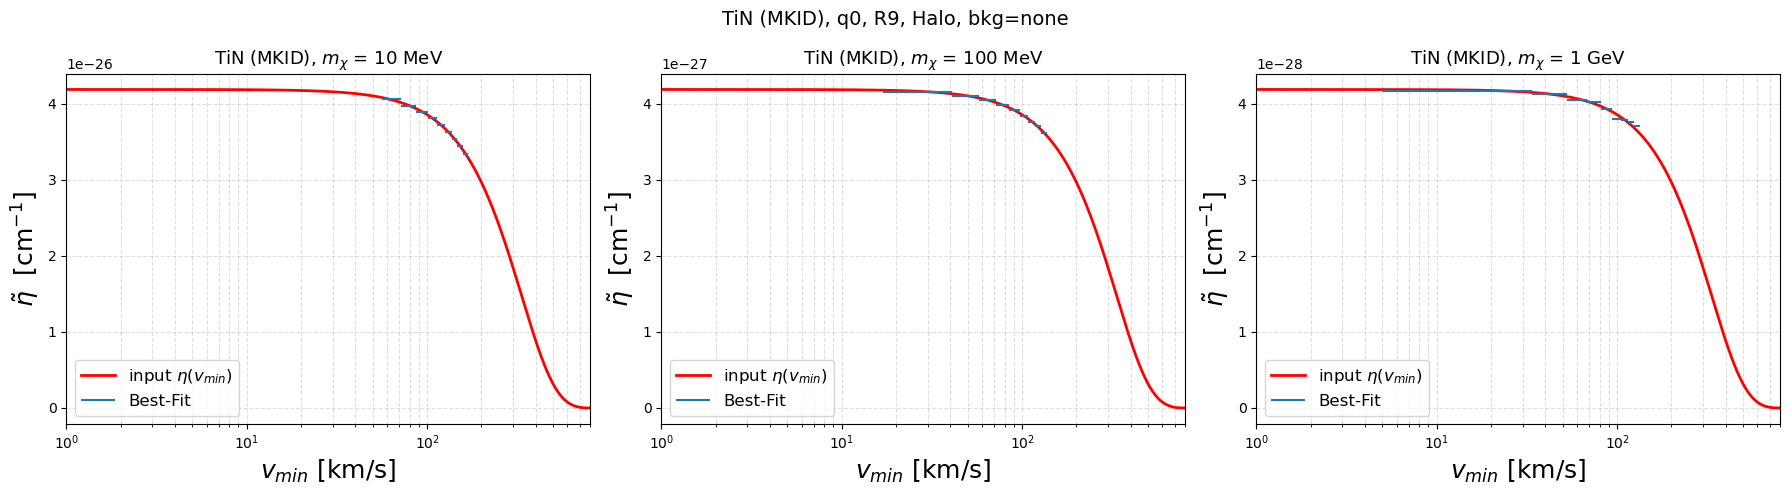

In [20]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

### Light mediator (q2), 9 energy bins

signal     : [ 6234.91651178  7186.16333068  9236.23755155  7555.13222378
 12896.38957588 14776.05147366 16520.79626466 17905.68778148
 18952.52575572]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_Halo/flux.pdf
TiN q2 M1 R9: 9 E-bins x 340 v_min bins, peak flux 7.85e+02
signal     : [ 680.368839    935.24050251 1172.68374157 1385.80806911 1571.65253501
 1728.03405846 1855.68630405 1954.94495003 2028.72876589]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_Halo/flux.pdf
TiN q2 M2 R9: 9 E-bins x 510 v_min bins, peak flux 8.11e+01
signal     : [ 70.26270477  95.73928457 119.22960173 140.20548484 158.38667765
 173.67922877 186.17146001 195.88988606 203.14086149]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_a

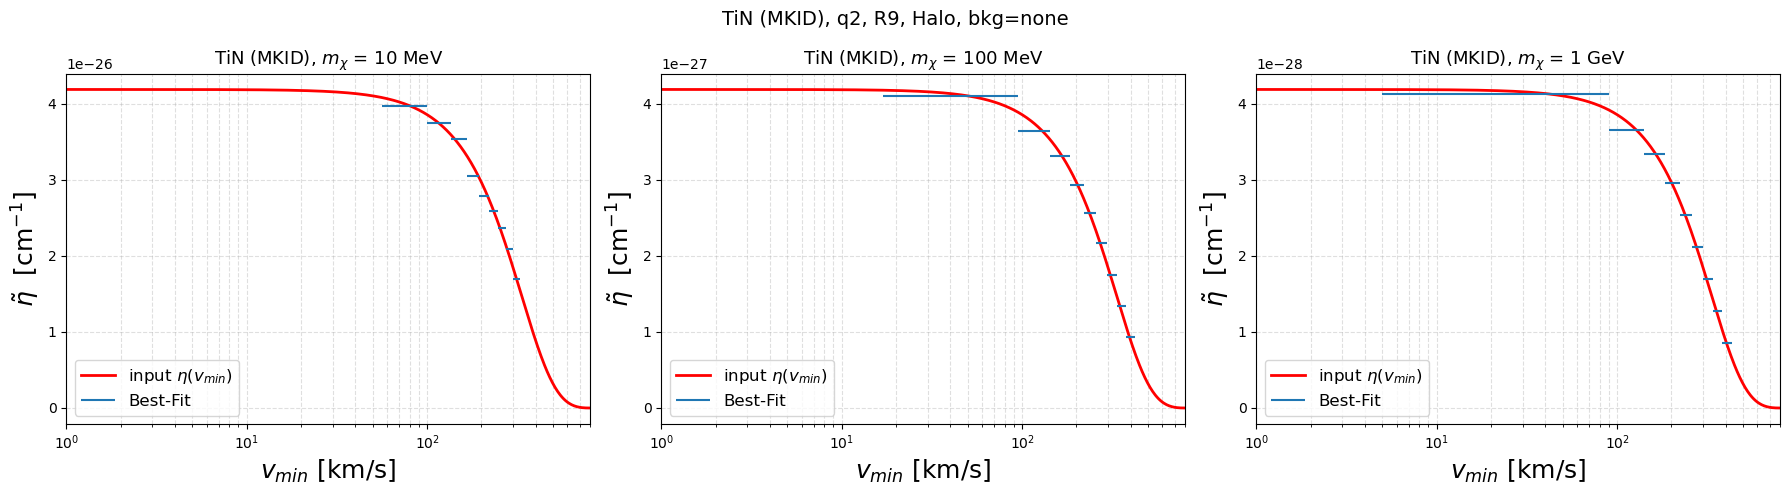

In [21]:
run_masses('TiN', q='2', nbins=9, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1368.50358669 3993.23105779 5407.69786811 6596.44688152 7724.69840788]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 136 v_min bins, peak flux 8.40e+02
signal     : [123.65867331 375.7866077  539.73916625 689.82712496 822.48136493]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 145 v_min bins, peak flux 8.84e+01
signal     : [12.30228222 37.42718975 53.96903514 69.11789391 82.63874624]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 157 v_min bins, peak flux 8.89e+00


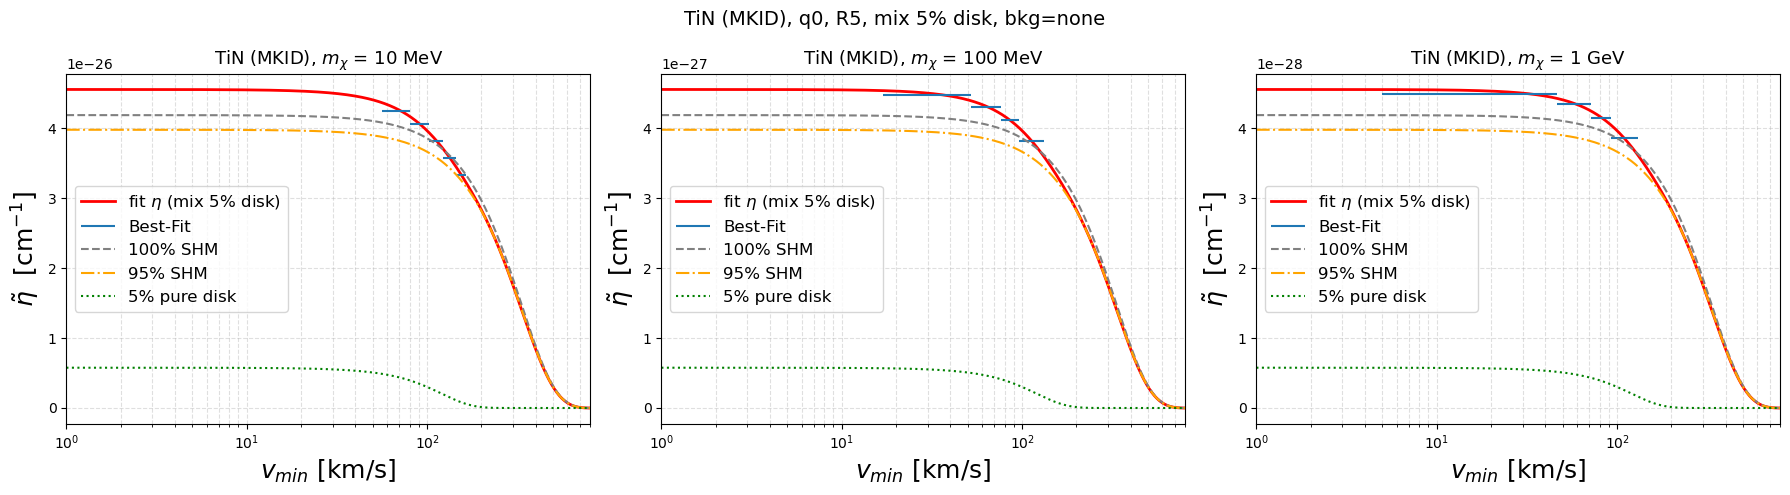

signal     : [1658.59114231 4621.0715088  5854.18931441 6640.19283881 7243.34161604]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 136 v_min bins, peak flux 1.03e+03
signal     : [161.69782074 483.8281849  674.07732063 823.82330411 927.39491981]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 145 v_min bins, peak flux 1.15e+02
signal     : [16.13872422 48.45065535 67.99066214 83.56835145 94.63585122]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 157 v_min bins, peak flux 1.16e+01


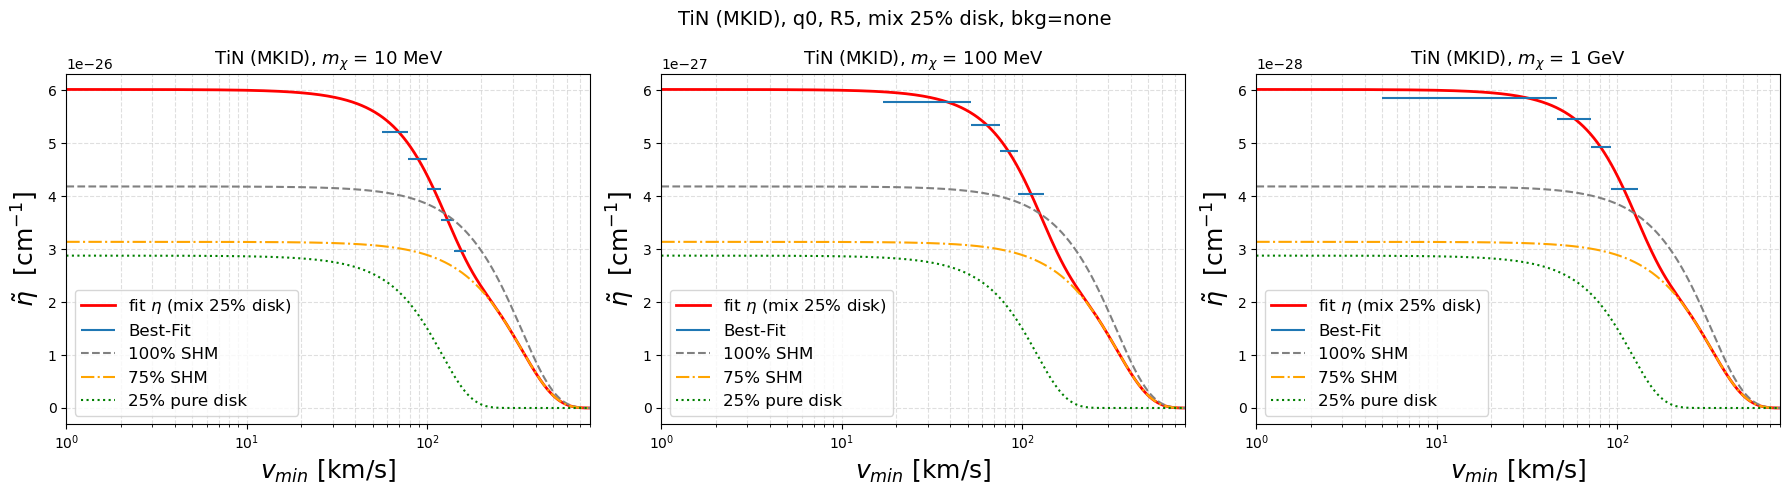

In [22]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

signal     : [ 6583.47967641 18805.82023317 22604.29403452 30525.02220193
 34626.86525034]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix5/flux.pdf
TiN q2 M1 R5: 5 E-bins x 333 v_min bins, peak flux 8.17e+02
signal     : [ 728.48965662 2135.8484392  2893.38901304 3427.73402598 3751.04604407]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix5/flux.pdf
TiN q2 M2 R5: 5 E-bins x 488 v_min bins, peak flux 8.66e+01
signal     : [ 75.19314261 216.39058957 291.8087013  344.5498873  376.42392506]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix5/flux.pdf
TiN q2 M3 R5: 5 E-bins x 514 v_min bins, peak flux 8.68e+00


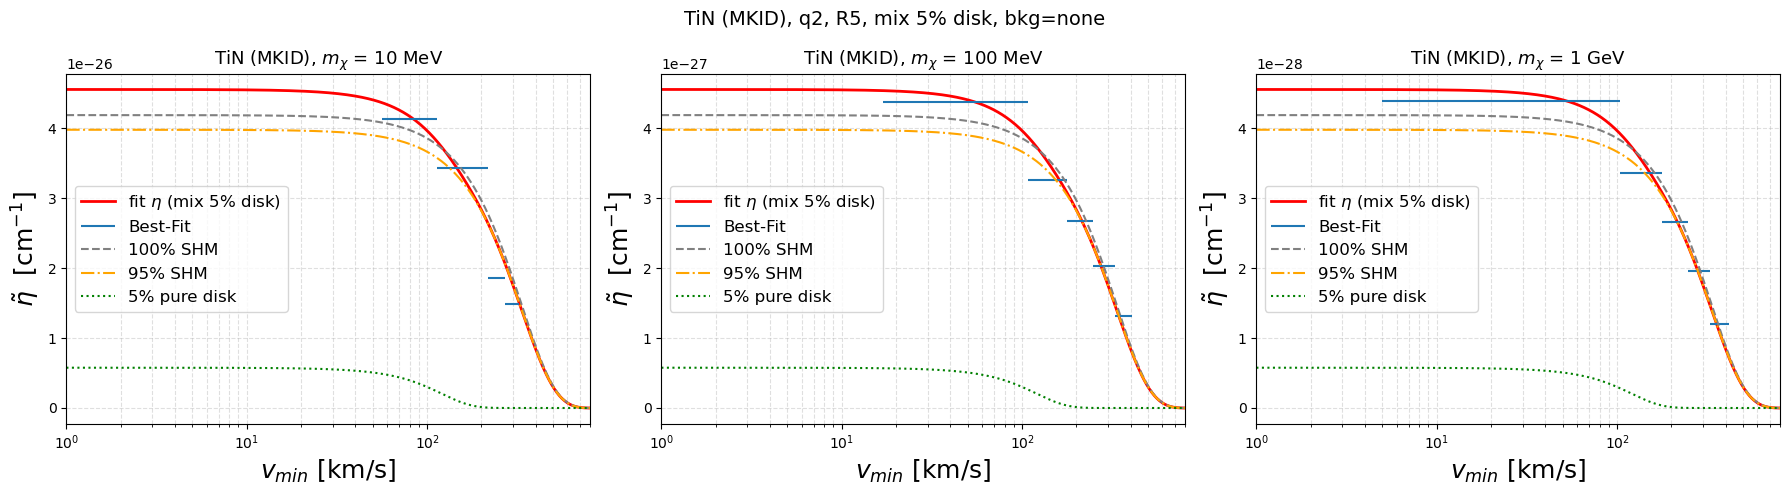

signal     : [ 7977.73233493 21054.58491881 23067.11351092 27868.81135995
 29723.33968756]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix25/flux.pdf
TiN q2 M1 R5: 5 E-bins x 333 v_min bins, peak flux 1.01e+03
signal     : [ 920.97292713 2512.22084047 3106.7384901  3417.26818966 3525.56570519]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix25/flux.pdf
TiN q2 M2 R5: 5 E-bins x 488 v_min bins, peak flux 1.14e+02
signal     : [ 94.914894   254.74658008 314.88632854 346.26714898 357.14363018]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix25/flux.pdf
TiN q2 M3 R5: 5 E-bins x 514 v_min bins, peak flux 1.14e+01


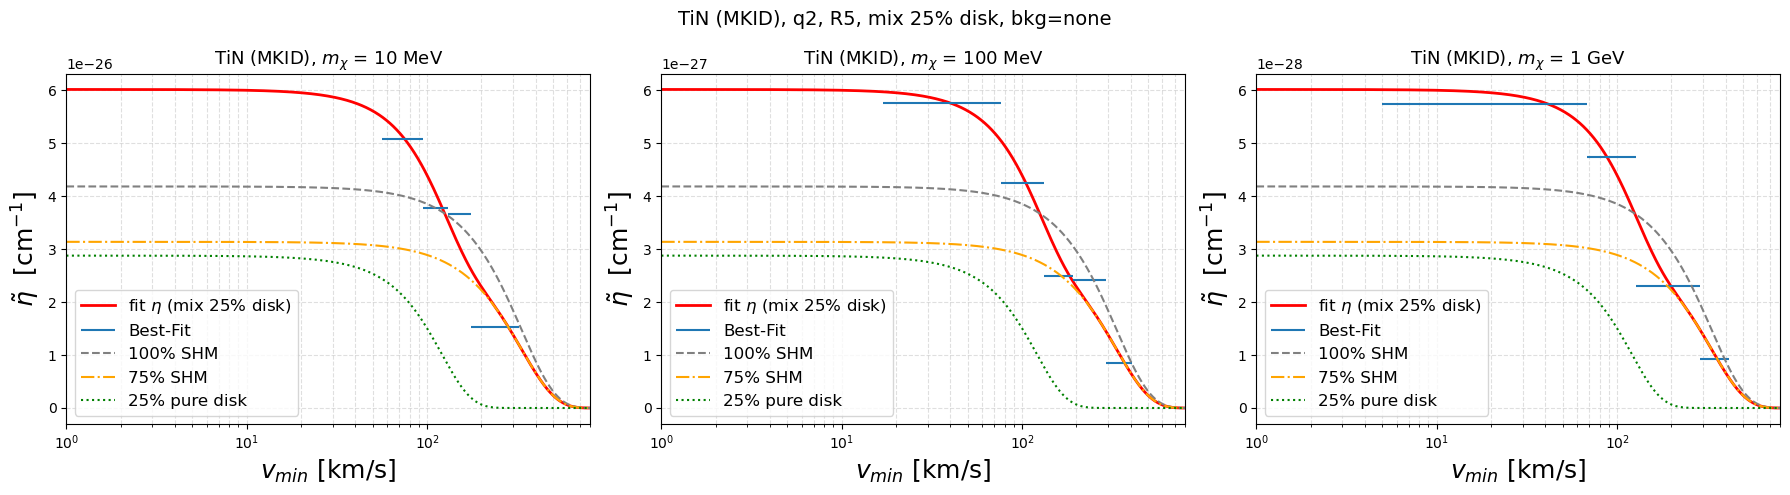

In [23]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 9 energy bins

signal     : [1368.50358669 1843.18957676 2251.90212482 2604.47508308 2886.65110916
 3226.31678783 3536.5268474  3850.17486763 4129.92337379]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 140 v_min bins, peak flux 8.53e+02
signal     : [123.65867331 169.4511592  213.68730145 256.59829983 298.12330683
 338.05836853 375.81739227 411.08231166 443.91449465]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 150 v_min bins, peak flux 8.91e+01
signal     : [12.30228222 16.8777299  21.35750318 25.66683105 29.89166081 33.87067404
 37.68670189 41.25805417 44.63001275]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

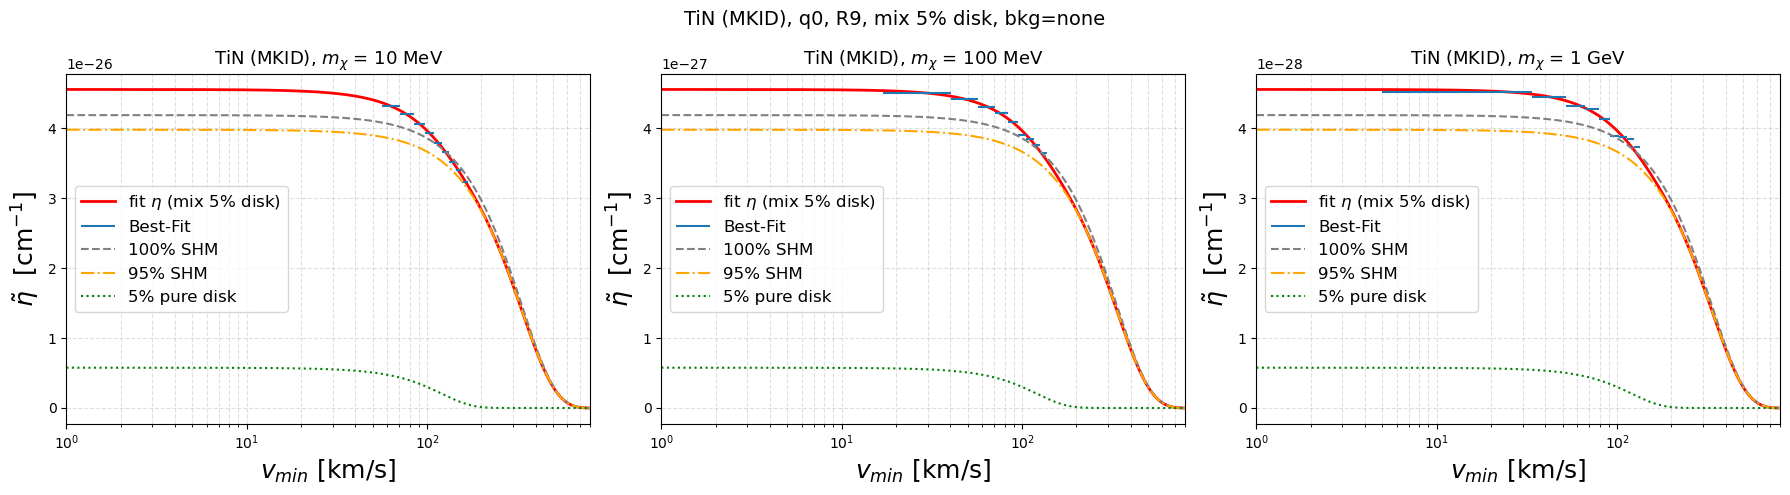

signal     : [1658.59114231 2171.39076253 2570.26077828 2874.71295196 3075.5349618
 3312.55505464 3500.22242522 3675.21447387 3812.32905252]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 140 v_min bins, peak flux 1.05e+03
signal     : [161.69782074 219.67003463 273.80715716 323.886542   369.34298211
 409.54362671 443.65495041 471.43418969 493.3355383 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 150 v_min bins, peak flux 1.16e+02
signal     : [16.13872422 21.98051291 27.532916   32.64924959 37.38373426 41.50291127
 45.08101911 48.02552234 50.40981043]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-no

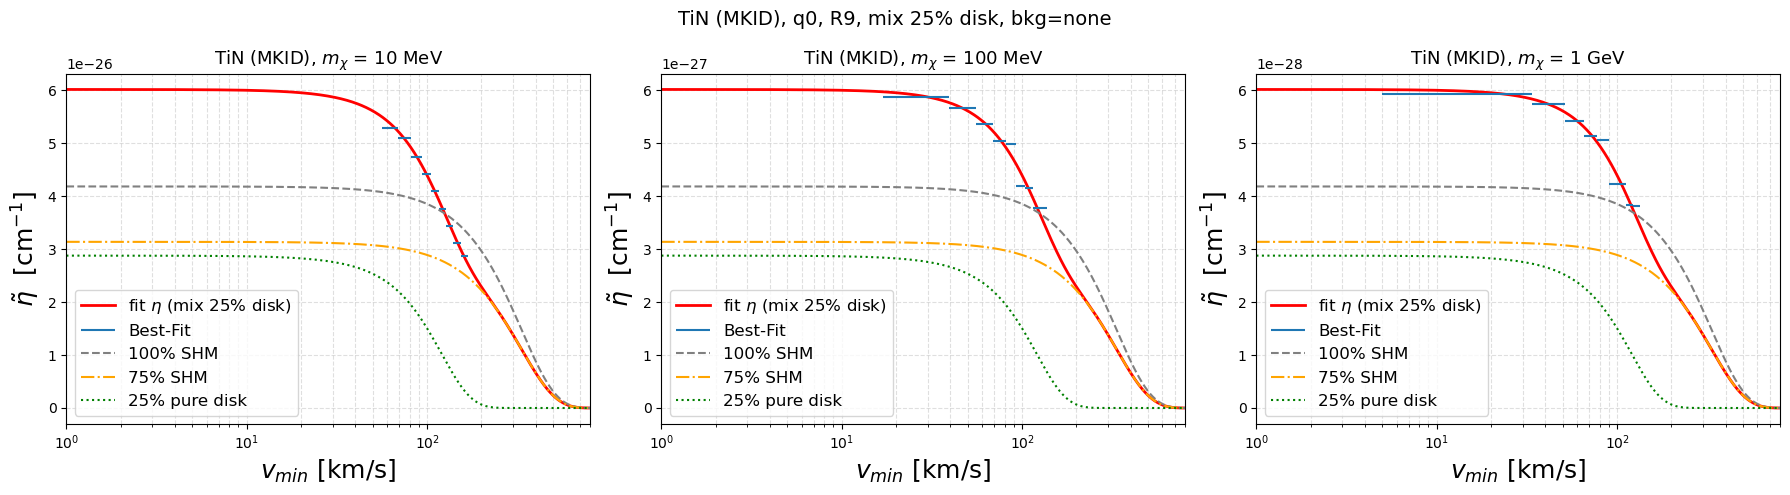

In [24]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

### Light mediator (q2), 9 energy bins

signal     : [ 6583.47967641  7502.50592743  9492.68303709  7722.35320018
 12862.04819731 14553.70243965 16115.13427112 17344.39288557
 18264.40837164]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix5/flux.pdf
TiN q2 M1 R9: 9 E-bins x 340 v_min bins, peak flux 8.33e+02
signal     : [ 728.48965662  987.4116546  1219.38506007 1421.20600161 1593.01868618
 1734.40003061 1847.08684914 1932.09527142 1992.77074526]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix5/flux.pdf
TiN q2 M2 R9: 9 E-bins x 510 v_min bins, peak flux 8.84e+01
signal     : [ 75.19314261 101.03155042 123.9959361  143.91425611 160.7771076
 174.64206153 185.69228762 194.02130936 199.97786468]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_an

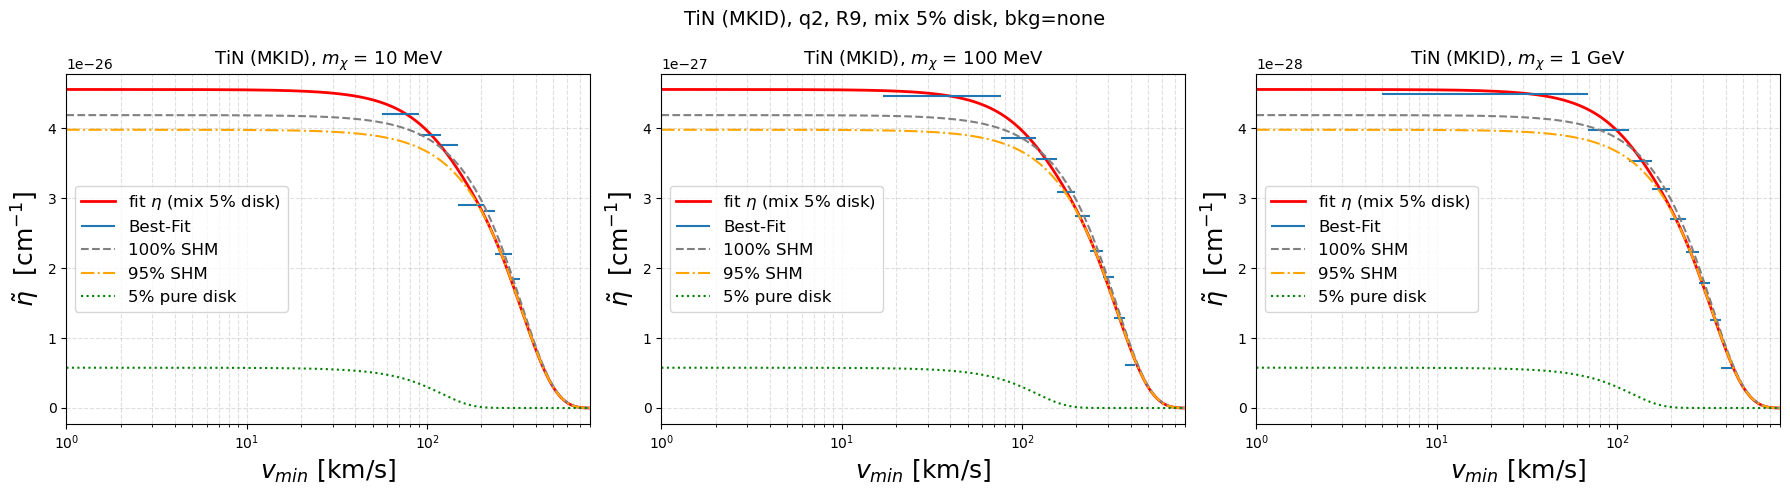

signal     : [ 7977.73233493  8767.87631443 10518.46497922  8391.23710575
 12724.68268303 13664.30630362 14492.48629696 15099.21330194
 15511.93883534]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix25/flux.pdf
TiN q2 M1 R9: 9 E-bins x 340 v_min bins, peak flux 1.04e+03
signal     : [ 920.97292713 1196.09626297 1406.19033403 1562.79773164 1678.48329088
 1759.86391924 1812.68902952 1840.696557   1848.93866275]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix25/flux.pdf
TiN q2 M2 R9: 9 E-bins x 510 v_min bins, peak flux 1.16e+02
signal     : [ 94.914894   122.20061384 143.06127357 158.74934118 170.33882742
 178.49339257 183.77559802 186.54700254 187.32587746]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor

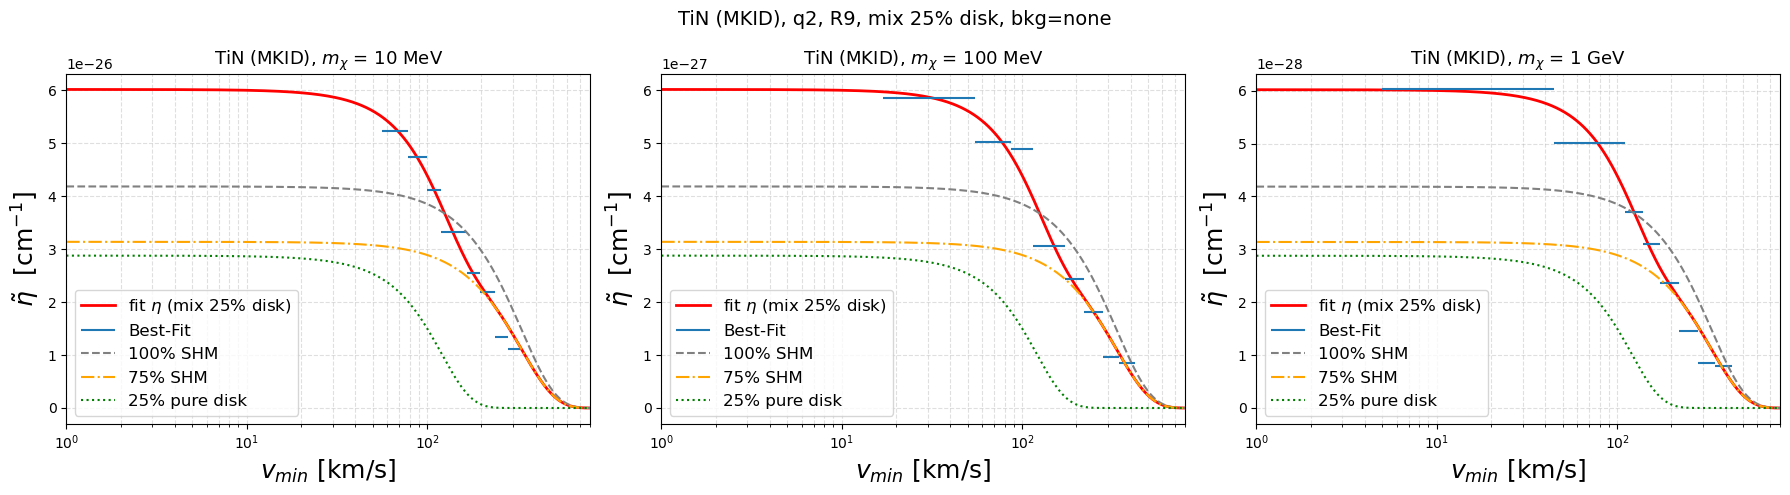

In [25]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=9, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [6.55781086e+09 9.72961717e+07 3.17520870e+04 7.46800314e+01
 7.96394700e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 157 v_min bins, peak flux 7.63e+13


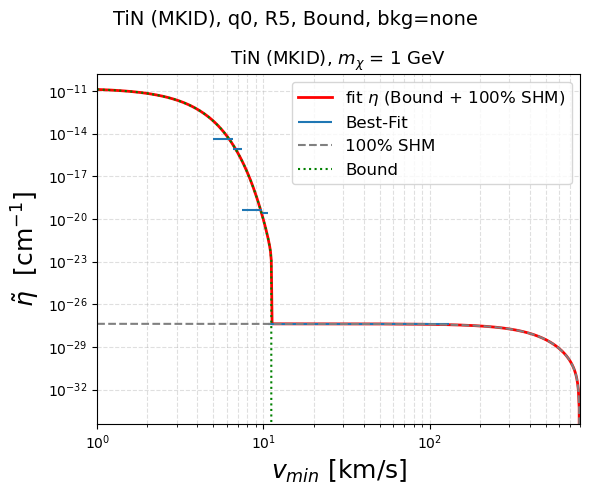

In [26]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [3.15490415e+07 1.36089556e+05 2.98034286e+02 3.44122294e+02
 3.81243999e+02]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Bound/flux.pdf
TiN q2 M3 R5: 5 E-bins x 514 v_min bins, peak flux 2.25e+13


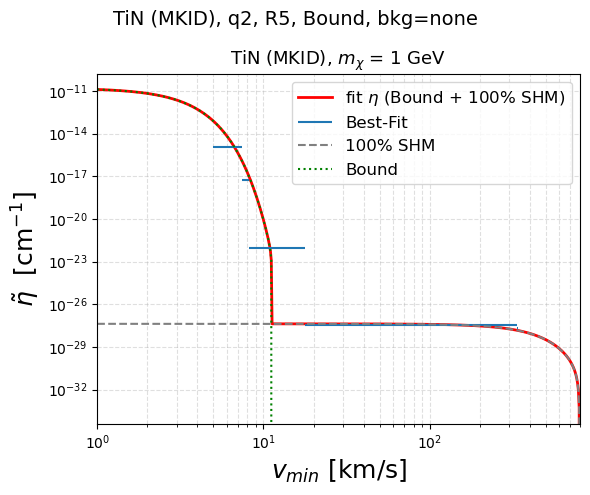

In [27]:
run_masses('TiN', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 9 energy bins

signal     : [6.55781086e+09 9.63103994e+07 1.51864406e+06 3.12976048e+04
 6.28609818e+02 4.11116350e+01 3.59363249e+01 3.95661871e+01
 4.31850633e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 162 v_min bins, peak flux 8.14e+13


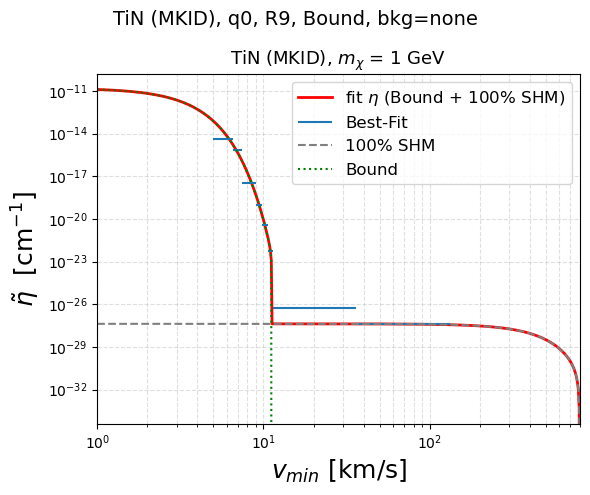

In [28]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))

### Light mediator (q2), 9 energy bins

signal     : [3.15490415e+07 1.35311816e+05 1.20455901e+03 1.52087102e+02
 1.58552339e+02 1.73680948e+02 1.86171470e+02 1.95889886e+02
 2.03140861e+02]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R9_Bound/flux.pdf
TiN q2 M3 R9: 9 E-bins x 537 v_min bins, peak flux 3.64e+13


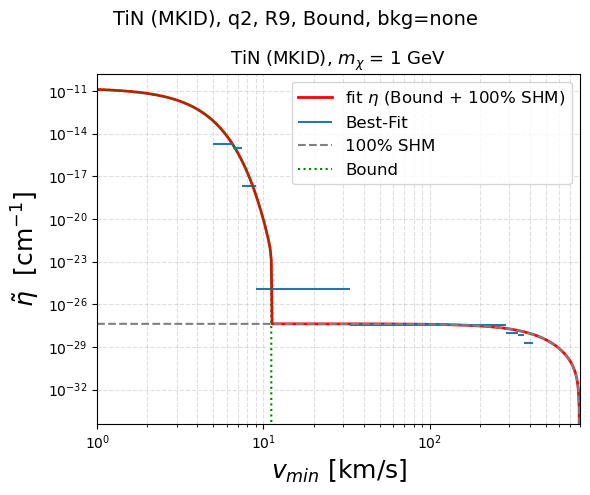

In [29]:
run_masses('TiN', q='2', nbins=9, eta='Bound', masses=('3',))